In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [12]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ankit\Downloads\german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [13]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB
None
        Unnamed: 0          Age          Job  Credit amount     Duration
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000
mean    499.500000    35.546000     1.904000    3271.258000    20.903000
std     288.819436    11.375469     0.653614    2822.736

In [41]:

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

if 'Saving accounts' in df.columns:
    df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')

if 'Checking account' in df.columns:
    df['Checking account'] = df['Checking account'].fillna('Unknown')

print(df.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [42]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())

   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                4                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 3           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   Duration  Purpose  
0         6        5  
1        48        5  
2        12        3  
3        42        4  
4        24        1  


In [52]:
target_col = [col for col in df.columns if 'Risk' in col]

print(target_col)

[]


In [60]:
for col in df.columns:
    print(col, df[col].nunique())

Age 53
Sex 2
Job 4
Housing 3
Saving accounts 5
Checking account 4
Credit amount 921
Duration 33
Purpose 8


In [62]:
print(df.columns.tolist())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [64]:
# show columns with unique values
for col in df.columns:
    print(col, df[col].nunique())

Age 53
Sex 2
Job 4
Housing 3
Saving accounts 5
Checking account 4
Credit amount 921
Duration 33
Purpose 8


In [65]:
target_col = None

for col in df.columns:
    if df[col].nunique() == 2:
        target_col = col
        print("Detected target column:", target_col)
        break

Detected target column: Sex


In [66]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(X.shape)
print(y.shape)

(1000, 8)
(1000,)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):

    print(f"\n{name}")
    print("-" * 30)

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))

In [73]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)


Logistic Regression
------------------------------
Accuracy : 0.71
Precision: 0.7222
Recall   : 0.942
F1 Score : 0.8176

Decision Tree
------------------------------
Accuracy : 0.675
Precision: 0.7267
Recall   : 0.8478
F1 Score : 0.7826

Random Forest
------------------------------
Accuracy : 0.66
Precision: 0.7134
Recall   : 0.8478
F1 Score : 0.7748


In [74]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.5573


In [75]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.42      0.24      0.31        62
           1       0.71      0.85      0.77       138

    accuracy                           0.66       200
   macro avg       0.57      0.54      0.54       200
weighted avg       0.62      0.66      0.63       200



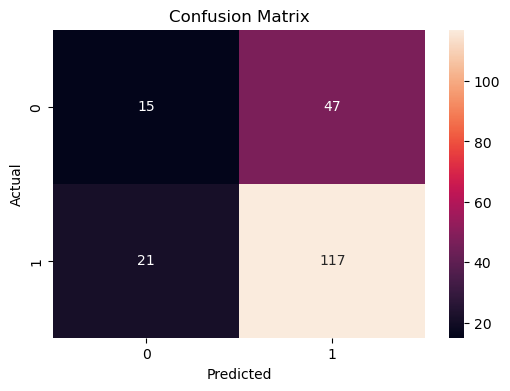

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [77]:
feature_names = X.columns

In [78]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

            Feature  Importance
0               Age    0.255669
5     Credit amount    0.250661
6          Duration    0.143215
7           Purpose    0.092177
4  Checking account    0.070167
3   Saving accounts    0.065489
2           Housing    0.063442
1               Job    0.059181
